In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [15]:
data = pd.read_excel("financial_literacy.xlsx")
print(data.head())

            Zaman damgası  \
0 2025-12-24 12:28:48.926   
1 2025-12-24 12:35:42.857   
2 2025-12-24 16:13:21.372   
3 2025-12-24 19:10:20.705   
4 2025-12-24 20:01:24.209   

    [Gelir ve giderlerimi yönetmek için nasıl bütçe yapacağımı biliyorum.]  \
0                                                  5                         
1                                                  2                         
2                                                  5                         
3                                                  3                         
4                                                  4                         

    [Enflasyonun paramın satın alma gücü üzerindeki etkisini tam olarak anlıyorum.]  \
0                                                  4                                  
1                                                  2                                  
2                                                  5                                  
3       

In [16]:
# ====================================================================
# CLASSIFICATION & EDA
# ====================================================================

In [17]:
data.columns

Index(['Zaman damgası',
       ' [Gelir ve giderlerimi yönetmek için nasıl bütçe yapacağımı biliyorum.]',
       ' [Enflasyonun paramın satın alma gücü üzerindeki etkisini tam olarak anlıyorum.]',
       ' [Faiz hesaplamalarının nasıl yapıldığını ve paranın zaman değerini biliyorum.]',
       ' [Mevduat hesapları, havale/EFT ücretleri gibi temel bankacılık işlemlerine hakimim.]',
       ' [Kredi kartı faiz oranlarının ve gecikme cezalarının nasıl işlediğini biliyorum.]',
       ' [Kredi notunun (Findeks puanı vb.) nasıl oluştuğunu ve ne işe yaradığını biliyorum.]',
       ' [İhtiyaç, taşıt veya konut kredisi çekme süreçleri hakkında yeterli bilgiye sahibim.]',
       ' [Birikmiş borçların nasıl yönetileceği veya yapılandırılacağı konusunda bilgi sahibiyim.]',
       ' [Hisse senetlerinin ve borsanın temel çalışma mantığını biliyorum.]',
       ' [Yatırım fonlarının (BES, Altın fonu vb.) risk ve getiri özelliklerini biliyorum.]',
       ' [Yatırım yaparken "Yüksek risk - Yüksek getiri" 

In [18]:
data = data.rename(columns=
                   {"  Mevcut birikimlerinizi değerlendirmek için kullandığınız yatırım araçları nelerdir? (Birden fazla işaretleyebilirsiniz)  ":"investment_tools"}
                  )
print(data.columns)

Index(['Zaman damgası',
       ' [Gelir ve giderlerimi yönetmek için nasıl bütçe yapacağımı biliyorum.]',
       ' [Enflasyonun paramın satın alma gücü üzerindeki etkisini tam olarak anlıyorum.]',
       ' [Faiz hesaplamalarının nasıl yapıldığını ve paranın zaman değerini biliyorum.]',
       ' [Mevduat hesapları, havale/EFT ücretleri gibi temel bankacılık işlemlerine hakimim.]',
       ' [Kredi kartı faiz oranlarının ve gecikme cezalarının nasıl işlediğini biliyorum.]',
       ' [Kredi notunun (Findeks puanı vb.) nasıl oluştuğunu ve ne işe yaradığını biliyorum.]',
       ' [İhtiyaç, taşıt veya konut kredisi çekme süreçleri hakkında yeterli bilgiye sahibim.]',
       ' [Birikmiş borçların nasıl yönetileceği veya yapılandırılacağı konusunda bilgi sahibiyim.]',
       ' [Hisse senetlerinin ve borsanın temel çalışma mantığını biliyorum.]',
       ' [Yatırım fonlarının (BES, Altın fonu vb.) risk ve getiri özelliklerini biliyorum.]',
       ' [Yatırım yaparken "Yüksek risk - Yüksek getiri" 

In [19]:
df = data[['investment_tools']].copy()
df["investment_tools"] = df['investment_tools'].str.split(', ')
print(df.head(10))

                                    investment_tools
0              [Altın / Döviz, Hisse Senedi (Borsa)]
1  [Mevduat / Katılım Hesabı (Faiz/Kar Payı), Alt...
2  [Altın / Döviz, Hisse Senedi (Borsa), Yatırım ...
3                                    [Altın / Döviz]
4                                    [Altın / Döviz]
5                                    [Altın / Döviz]
6              [Altın / Döviz, Hisse Senedi (Borsa)]
7                   [Altın / Döviz, Yatırım Fonları]
8  [Hisse Senedi (Borsa), Kripto Varlıklar, Birey...
9  [Altın / Döviz, Bireysel Emeklilik Sistemi (BES)]


In [20]:
df_tools = df['investment_tools'].str.join('|').str.get_dummies()
df_tools.head()

,Altın / Döviz,Bireysel Emeklilik Sistemi (BES),Hisse Senedi (Borsa),Hiçbiri / Sadece Nakit,Kripto Varlıklar,Mevduat / Katılım Hesabı (Faiz/Kar Payı),Yatırım Fonları
0,1,0,1,0,0,0,0
1,1,0,1,0,0,1,1
2,1,0,1,0,1,0,1
3,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0


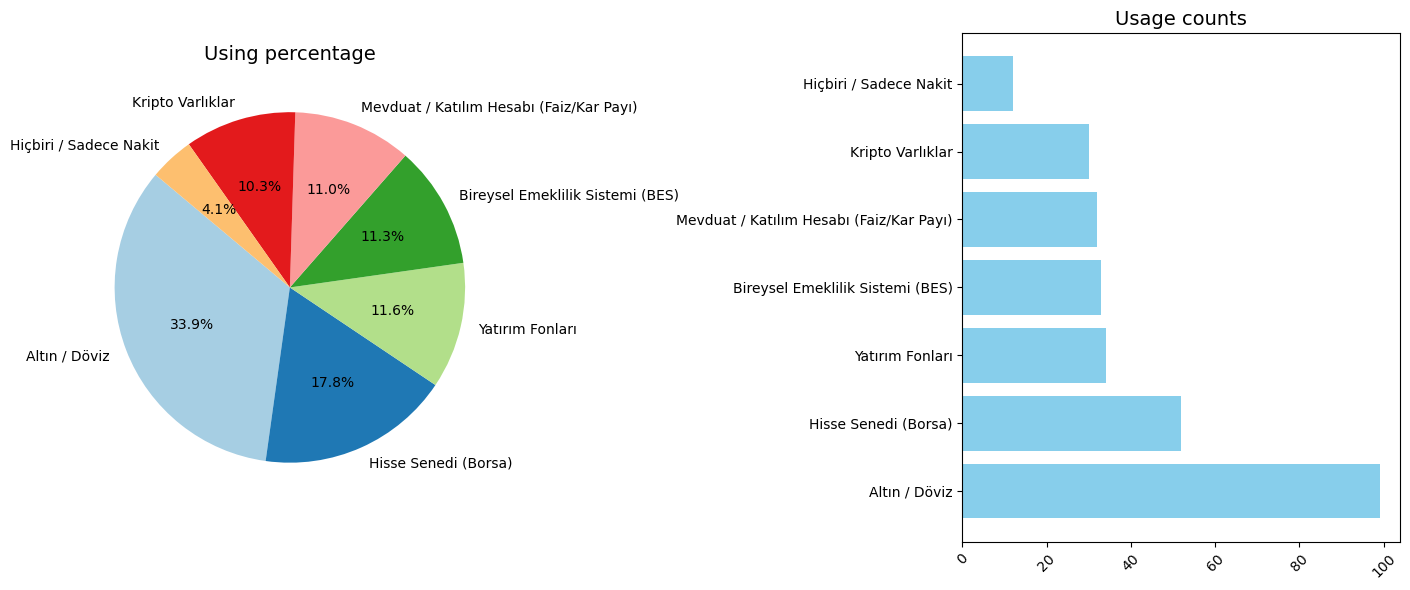

In [27]:
# Veriyi hesapla
popular_tools = df_tools.sum().sort_values(ascending=False)

# Grafik alanını oluştur
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- SOLDAKİ PASTA GRAFİĞİ ---
axes[0].pie(
    popular_tools, 
    labels=popular_tools.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Paired.colors
)
axes[0].set_title("Using percentage", fontsize=14)

# --- SAĞDAKİ SÜTUN GRAFİĞİ ---
axes[1].barh(popular_tools.index, popular_tools.values, color='skyblue')
axes[1].set_title("Usage counts", fontsize=14)

# Yazıların çakışmaması için eksen üzerinden döndürme yapalım
axes[1].tick_params(axis='x', rotation=45) 

# Düzenleme ve Gösterme
plt.tight_layout()
plt.show()

# Basket Analyze

In [34]:
# 1. Adım: Sık kullanılan yatırım araçları setlerini bulalım
frequent_itemsets = apriori(df_tools, min_support=0.05, use_colnames=True)

# 2. Adım: Kuralları oluşturma (Lift > 1 olanları alıyoruz)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Sadece 'antecedents' ve 'consequents' içinde 1 tane eleman olanları seçiyoruz
rules = rules[
    (rules['antecedents'].apply(lambda x: len(x) == 1)) & 
    (rules['consequents'].apply(lambda x: len(x) == 1))
].copy()

# Parantezli (frozenset) görünümü temizleyip sadece metin olarak bırakıyoruz
rules['antecedents'] = rules['antecedents'].apply(lambda x: list(x)[0])
rules['consequents'] = rules['consequents'].apply(lambda x: list(x)[0])

# 3. Adım: Sonuçları anlamlılık (Lift) değerine göre sıralayalım
rules = rules.sort_values('lift', ascending=False)

# En önemli kuralları (En güçlü 10 ilişkiyi) görelim
print("Top 10 Single-Item Association Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Top 10 Single-Item Association Rules:
                                 antecedents  \
17                      Hisse Senedi (Borsa)   
16                          Kripto Varlıklar   
10                          Kripto Varlıklar   
11          Bireysel Emeklilik Sistemi (BES)   
23                          Kripto Varlıklar   
22  Mevduat / Katılım Hesabı (Faiz/Kar Payı)   
27                           Yatırım Fonları   
26  Mevduat / Katılım Hesabı (Faiz/Kar Payı)   
18  Mevduat / Katılım Hesabı (Faiz/Kar Payı)   
19                      Hisse Senedi (Borsa)   

                                 consequents   support  confidence      lift  
17                          Kripto Varlıklar  0.210084    0.480769  1.907051  
16                      Hisse Senedi (Borsa)  0.210084    0.833333  1.907051  
10          Bireysel Emeklilik Sistemi (BES)  0.117647    0.466667  1.682828  
11                          Kripto Varlıklar  0.117647    0.424242  1.682828  
23  Mevduat / Katılım Hesabı (Faiz/Kar

In [42]:
metrics = [
    ('support', 'MOST COMMON COMBINATIONS (Popularity)'),
    ('confidence', 'STRONGEST PREDICTIONS (Reliability)'),
    ('lift', 'MOST SIGNIFICANT RELATIONSHIPS (Impact)')
]

print("="*85)
print(f"{'INVESTMENT BASKET ANALYSIS SUMMARY':^85}")
print("="*85)

for metric_key, metric_name in metrics:
    top_3 = rules.sort_values(metric_key, ascending=False).head(3)
    
    print(f"\n>>> {metric_name}")
    print(f"{'Relationship':<60} | {metric_key.upper()}")
    print("-" * 75)
    
    for _, row in top_3.iterrows():
        rel = f"{row['antecedents']}  --->  {row['consequents']}"
                
        val = f"%{row[metric_key]*100:.1f}" if metric_key == 'confidence' else f"{row[metric_key]:.2f}"
        
        print(f"{rel:<60} | {val}")
    print("-" * 75)

print("\n" + "="*85)

                         INVESTMENT BASKET ANALYSIS SUMMARY                          

>>> MOST COMMON COMBINATIONS (Popularity)
Relationship                                                 | SUPPORT
---------------------------------------------------------------------------
Hisse Senedi (Borsa)  --->  Altın / Döviz                    | 0.38
Altın / Döviz  --->  Hisse Senedi (Borsa)                    | 0.38
Altın / Döviz  --->  Mevduat / Katılım Hesabı (Faiz/Kar Payı) | 0.25
---------------------------------------------------------------------------

>>> STRONGEST PREDICTIONS (Reliability)
Relationship                                                 | CONFIDENCE
---------------------------------------------------------------------------
Mevduat / Katılım Hesabı (Faiz/Kar Payı)  --->  Altın / Döviz | %93.8
Hisse Senedi (Borsa)  --->  Altın / Döviz                    | %86.5
Bireysel Emeklilik Sistemi (BES)  --->  Altın / Döviz        | %84.8
--------------------------------------------

In [43]:
excel = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
excel.columns = ['first_tool', 'second_tool', 'support', 'confidence', 'lift']
excel.to_excel("Investment_Basket_Analysis.xlsx",index=False)